In [ ]:
# !pip install slycot   # optional
# !pip install control

In [ ]:
from control.matlab import *
import numpy as np
import matplotlib.pyplot as plt
#%%
#Expert PID Controller

konversi plant kontitnyu ke digital

In [ ]:
ts=0.001
sys=tf(5.235e005,[1, 87.35, 1.047e004, 0]) #Plant
dsys=c2d(sys,ts,'zoh')
[num,den]=tfdata(dsys)
num = num[0][0]
den = den[0][0]
#np.insert(np.zeros(1),1,num,axis=0)
print(num)
print(den)

[8.53331265e-05 3.33831370e-04 8.16859077e-05]
[ 1.         -2.90633931  2.82269562 -0.91635631]


simulasi kontrol PID

In [ ]:
u_1=0; u_2=0; u_3=0; u_4=0
y_1=0; y_2=0; y_3=0
ei=0
error_1=0;derror_1=0
kp=0.6;ki=0.03;kd=0.01

<function matplotlib.pyplot.show(close=None, block=None)>

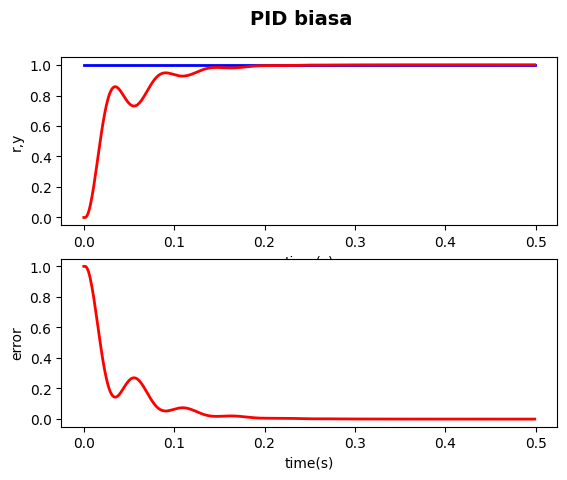

In [ ]:
iter=500
waktu = np.zeros(iter)
yd=np.ones(iter)
y=np.zeros(iter)
error = np.zeros(iter)
derror = np.zeros(iter)
u = np.zeros(iter)
#%%
for k in range(iter):
    waktu[k]=k*ts
    y[k]=-den[1]*y_1-den[2]*y_2-den[3]*y_3+0*u_1 +num[0]*u_2+num[1]*u_3+num[2]*u_4
    error[k]=yd[k]-y[k]
    # Calculating P
    derror[k]=error[k]-error_1
    # Calculating D
    ei=ei+error[k]*ts
    u[k]=kp*error[k]+kd*derror[k]/ts+ki*ei; #PID Controller

    u_4=u_3;u_3=u_2;u_2=u_1;u_1=u[k]
    y_3=y_2;y_2=y_1;y_1=y[k]
    error_1=error[k]
#%%
# plot
fig = plt.figure()
fig.suptitle('PID biasa', fontsize=14, fontweight='bold')
ax1 = fig.add_subplot(211)
ax1.plot(waktu,yd,color='blue', linewidth=2)
ax1.plot(waktu,y,color='red', linewidth=2)
ax1.set_xlabel('time(s)')
ax1.set_ylabel('r,y')
#ax1.set_title('Output target(biru) dan aktual (merah)')
ax2 = fig.add_subplot(212)
ax2.plot(waktu,yd-y,color='red',linewidth=2)
ax2.set_xlabel('time(s)')
ax2.set_ylabel('error')
#ax2.set_title('Kesalahan')
plt.show
